In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [12]:
project_root = Path("/home/akapociu/ift/interactiondynamics")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from data.spring_web_2d import SpringWeb2DConfig, SpringWeb2DDataset

In [ ]:
cfg = SpringWeb2DConfig(
    num_nodes=32,
    num_bins=256,
    interaction_threshold=0.0,   # set to 0 so we can inspect essentially all ring edges
    bidirectional=True,
    seed=0,
    topology="knn",
    topology_k=4,
    # topology_radius="0.5",
)

ds = SpringWeb2DDataset(cfg)
spec = ds.spec()
spec

DataSpec(name='spring_web_2d', num_nodes=32, event_dim=8, num_events=32768, num_bins=256, extra={'feature_names': ['dx', 'dy', 'dvx', 'dvy', 'dist', 'extension', 'fx', 'fy'], 'physics': '2D spring-mass web on noisy ring geometry', 'topology': 'knn', 'topology_k': 4, 'topology_radius': '0.5', 'include_ring_edges': True, 'event_mode': 'thresholded', 'interaction_threshold': 0.0, 'threshold_metric': 'force_mag', 'threshold_use_absolute': True, 'target_type': 'delta_v', 'target_horizon': 1, 'standardize_node_targets': True, 'node_target_dim': 2, 'node_target_names': ['delta_vx_std', 'delta_vy_std']})

In [14]:
batch0 = next(iter(ds.bins("train")))
print(batch0.src[:10])
print(batch0.dst[:10])
print(batch0.features.shape if batch0.features is not None else None)
print(spec)

tensor([ 0,  1,  0,  2,  0, 30,  0, 31,  1,  2])
tensor([ 1,  0,  2,  0, 30,  0, 31,  0,  2,  1])
torch.Size([128, 8])
DataSpec(name='spring_web_2d', num_nodes=32, event_dim=8, num_events=32768, num_bins=256, extra={'feature_names': ['dx', 'dy', 'dvx', 'dvy', 'dist', 'extension', 'fx', 'fy'], 'physics': '2D spring-mass web on noisy ring geometry', 'topology': 'knn', 'topology_k': 4, 'topology_radius': '0.5', 'include_ring_edges': True, 'event_mode': 'thresholded', 'interaction_threshold': 0.0, 'threshold_metric': 'force_mag', 'threshold_use_absolute': True, 'target_type': 'delta_v', 'target_horizon': 1, 'standardize_node_targets': True, 'node_target_dim': 2, 'node_target_names': ['delta_vx_std', 'delta_vy_std']})


THRESHOLD OPTIONS FOR SPRING RING / SPRING-WEB-STYLE ANALYSIS:

We build the spring-ring dataset with `force_threshold=0.0` so we can inspect
essentially **all** physical ring edges first, then estimate percentile-based
cutoffs for several candidate threshold metrics.

Stored edge features are:
- dx, dy     : relative displacement vector
- dvx, dvy   : relative velocity vector
- dist       : current spring length
- extension  : dist - rest_length
- fx, fy     : spring force vector components

From those, we can analyze these candidate threshold quantities:

- `force_mag`      = sqrt(fx^2 + fy^2)
- `distance`       = dist
- `rel_speed`      = sqrt(dvx^2 + dvy^2)
- `extension_raw`  = extension
- `extension_abs`  = abs(extension)

Notes:
- `force_mag`, `distance`, and `rel_speed` are already nonnegative, so
  `threshold_use_absolute=True/False` does not matter for them.
- `extension` is signed, so we report both:
  - `extension_raw` for one-sided signed thresholding
  - `extension_abs` for magnitude-based thresholding
- `all_neighbors` means **no threshold at all** and is the dense baseline.

For every emitted ring edge in every bin of the chosen split, we compute the
candidate threshold metrics listed above and then:

1. summarize each metric distribution,
2. report percentile cutoffs,
3. estimate how many edges/bin would survive if that percentile were used as the threshold.

This gives percentile-based threshold candidates for the newer threshold options
without having to rerun training first.

feature_idx: {'dx': 0, 'dy': 1, 'dvx': 2, 'dvy': 3, 'dist': 4, 'extension': 5, 'fx': 6, 'fy': 7}
num bins inspected: 38
edges per bin (first few): [64, 64, 64, 64, 64, 64, 64, 64, 64, 64]
mean edges/bin before thresholding: 64.00

=== force_mag ===
count: 2432
min:   4.70877e-06
mean:  0.0319593
std:   0.0235531
max:   0.113519
p25:   0.0140746
p50:   0.027585
p75:   0.0422157
p90:   0.0685314
p95:   0.0827594
p99:   0.0983724
all_neighbors baseline mean kept/bin = 64.00

--- Estimated sparsity by percentile cutoff for force_mag ---
p25 threshold = 0.0140746 | mean kept/bin = 48.00 | median = 48.00 | min = 40 | max = 54
p50 threshold = 0.027585 | mean kept/bin = 32.00 | median = 34.00 | min = 24 | max = 40
p75 threshold = 0.0422157 | mean kept/bin = 16.00 | median = 16.00 | min = 6 | max = 24
p90 threshold = 0.0685314 | mean kept/bin = 6.42 | median = 6.00 | min = 2 | max = 12
p95 threshold = 0.0827594 | mean kept/bin = 3.21 | median = 4.00 | min = 0 | max = 8
p99 threshold = 0.0983724

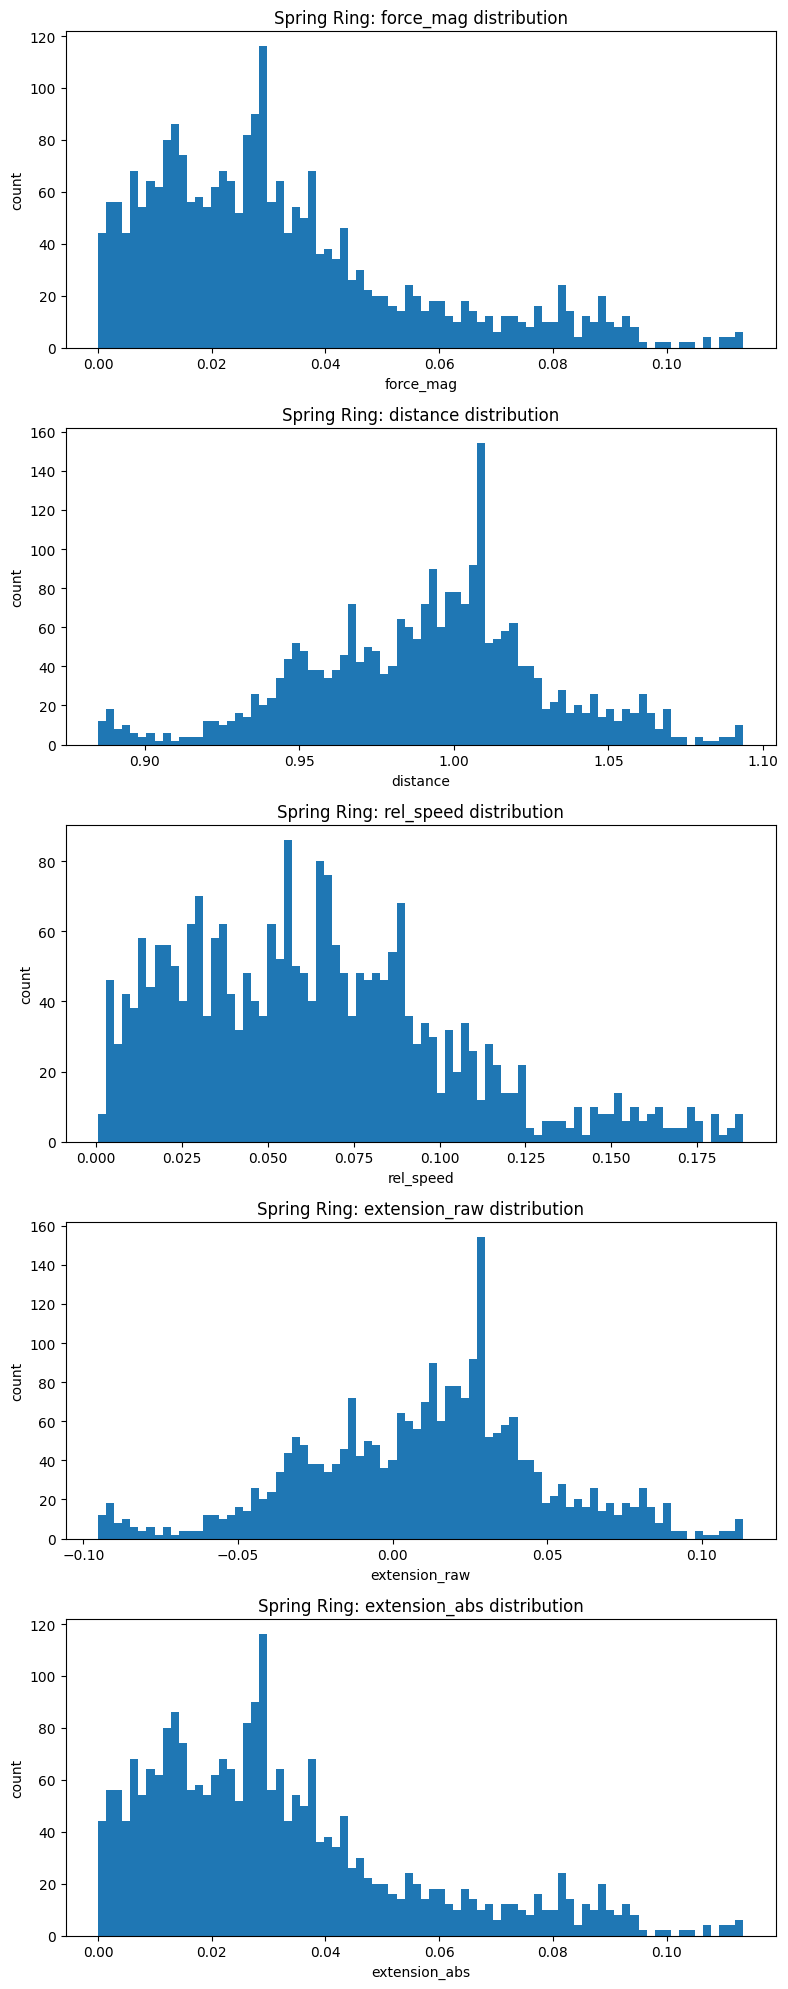

In [11]:
# -----------------------------
# config
# -----------------------------
split = "val"          # or "train" / "val" / "test"
percentiles = [25, 50, 75, 90, 95, 99]

# -----------------------------
# spring ring feature layout
# must match data.spring_ring.SpringWeb2DDataset
# [dx, dy, dvx, dvy, dist, extension, fx, fy]
# -----------------------------
feature_names = ["dx", "dy", "dvx", "dvy", "dist", "extension", "fx", "fy"]
feature_idx = {name: i for i, name in enumerate(feature_names)}
print("feature_idx:", feature_idx)

# -----------------------------
# collect per-bin values
# -----------------------------
metrics_all = {
    "force_mag": [],
    "distance": [],
    "rel_speed": [],
    "extension_raw": [],
    "extension_abs": [],
}
metrics_by_bin = {k: [] for k in metrics_all}
edges_per_bin = []

for batch in ds.bins(split):
    if batch.features is None:
        continue

    feats = batch.features.detach().cpu().numpy()   # [num_edges, 8]
    edges_per_bin.append(feats.shape[0])

    dx = feats[:, feature_idx["dx"]]
    dy = feats[:, feature_idx["dy"]]
    dvx = feats[:, feature_idx["dvx"]]
    dvy = feats[:, feature_idx["dvy"]]
    dist = feats[:, feature_idx["dist"]]
    extension = feats[:, feature_idx["extension"]]
    fx = feats[:, feature_idx["fx"]]
    fy = feats[:, feature_idx["fy"]]

    metric_vals = {
        "force_mag": np.sqrt(fx**2 + fy**2),
        "distance": dist,
        "rel_speed": np.sqrt(dvx**2 + dvy**2),
        "extension_raw": extension,
        "extension_abs": np.abs(extension),
    }

    for name, vals in metric_vals.items():
        metrics_all[name].append(vals)
        metrics_by_bin[name].append(vals)

print(f"num bins inspected: {len(edges_per_bin)}")
print(f"edges per bin (first few): {edges_per_bin[:10]}")
print(f"mean edges/bin before thresholding: {np.mean(edges_per_bin):.2f}")

for name in list(metrics_all.keys()):
    metrics_all[name] = np.concatenate(metrics_all[name]) if metrics_all[name] else np.array([])

# -----------------------------
# helper for kept/bin estimates
# -----------------------------
def keep_rule(metric_name, vals_bin, thr):
    if metric_name == "extension_raw":
        # one-sided signed thresholding: keep extension >= threshold
        return vals_bin >= thr
    # all others use magnitude / nonnegative thresholding
    return vals_bin >= thr

# -----------------------------
# summary stats + percentile cutoffs
# -----------------------------
for name, vals in metrics_all.items():
    print("\n" + "=" * 70)
    print(f"=== {name} ===")
    print(f"count: {len(vals)}")
    print(f"min:   {vals.min():.6g}")
    print(f"mean:  {vals.mean():.6g}")
    print(f"std:   {vals.std():.6g}")
    print(f"max:   {vals.max():.6g}")

    pct_map = {}
    for p in percentiles:
        thr = float(np.percentile(vals, p))
        pct_map[p] = thr
        print(f"p{p}:   {thr:.6g}")

    print(f"all_neighbors baseline mean kept/bin = {np.mean(edges_per_bin):.2f}")

    print(f"\n--- Estimated sparsity by percentile cutoff for {name} ---")
    for p in percentiles:
        thr = pct_map[p]

        kept_counts = []
        for vals_bin in metrics_by_bin[name]:
            kept = keep_rule(name, vals_bin, thr).sum()
            kept_counts.append(int(kept))

        kept_counts = np.asarray(kept_counts)

        print(
            f"p{p:>2} threshold = {thr:.6g} | "
            f"mean kept/bin = {kept_counts.mean():.2f} | "
            f"median = {np.median(kept_counts):.2f} | "
            f"min = {kept_counts.min()} | "
            f"max = {kept_counts.max()}"
        )

# -----------------------------
# histograms
# -----------------------------
plot_order = ["force_mag", "distance", "rel_speed", "extension_raw", "extension_abs"]
fig, axes = plt.subplots(len(plot_order), 1, figsize=(8, 4 * len(plot_order)))

for ax, name in zip(axes, plot_order):
    vals = metrics_all[name]
    ax.hist(vals, bins=80)
    ax.set_title(f"Spring Ring: {name} distribution")
    ax.set_xlabel(name)
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter

split = "val"

edge_counts = []
for batch in ds.bins(split):
    n_edges = int(batch.src.numel())
    edge_counts.append(n_edges)

edge_counts = np.array(edge_counts)

print(f"=== Edge count stats for split={split!r} ===")
print(f"num_bins:         {len(edge_counts)}")
print(f"total_edges:      {edge_counts.sum()}")
print(f"min_edges/bin:    {edge_counts.min()}")
print(f"max_edges/bin:    {edge_counts.max()}")
print(f"mean_edges/bin:   {edge_counts.mean():.2f}")
print(f"median_edges/bin: {np.median(edge_counts):.2f}")
print(f"std_edges/bin:    {edge_counts.std():.2f}")
print(f"first 10 bins:    {edge_counts[:10].tolist()}")

count_freq = Counter(edge_counts.tolist())

print("\n=== Bin count frequency ===")
for edge_count in sorted(count_freq):
    print(f"{count_freq[edge_count]} bins have {edge_count} edges")

=== Edge count stats for split='val' ===
num_bins:         38
total_edges:      2432
min_edges/bin:    64
max_edges/bin:    64
mean_edges/bin:   64.00
median_edges/bin: 64.00
std_edges/bin:    0.00
first 10 bins:    [64, 64, 64, 64, 64, 64, 64, 64, 64, 64]

=== Bin count frequency ===
38 bins have 64 edges
